#K-Means for Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score

## Load data

In [ ]:
#!gdown 16w9m7CK-vsTZrvw3XMROdkWLiasOxw68

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.drop("CustomerID", axis=1, inplace=True)

In [7]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


## EDA

In [8]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

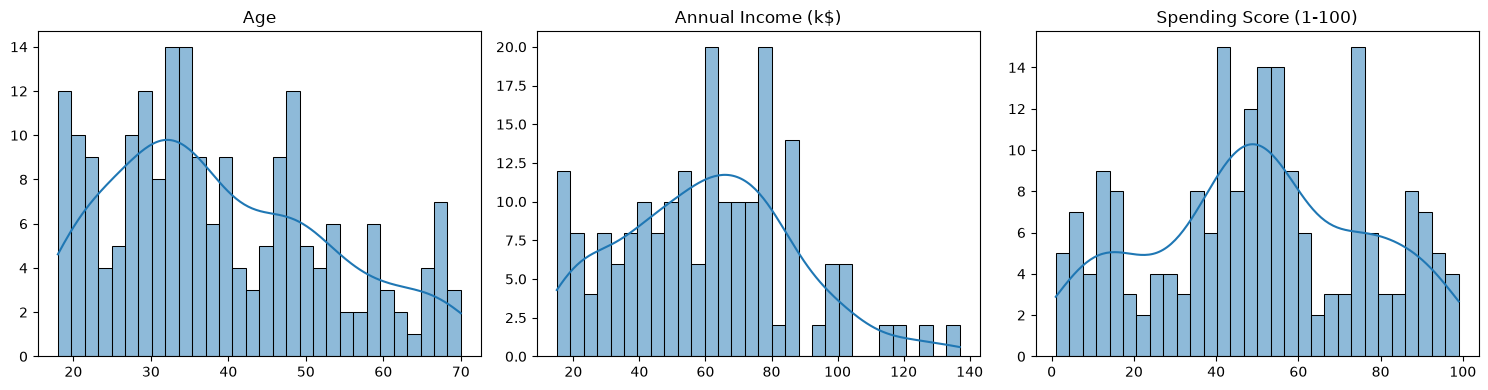

In [9]:
plot_all_histograms(df)

<Axes: xlabel='Gender', ylabel='count'>

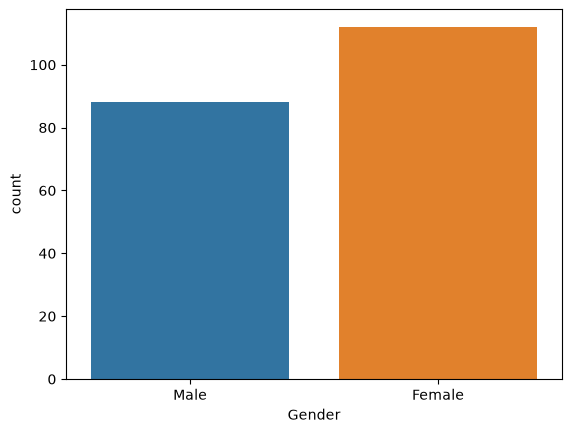

In [10]:
sns.countplot(data=df, x="Gender", hue="Gender")

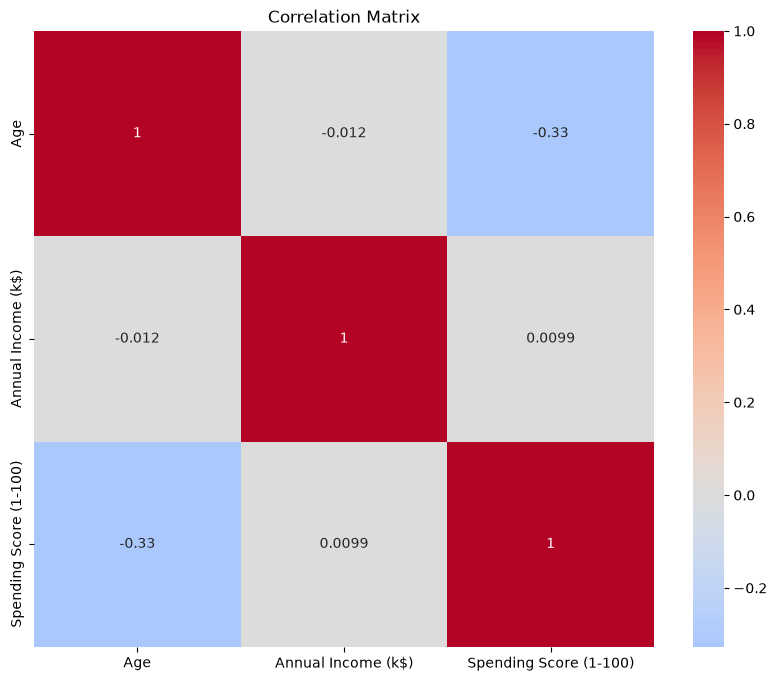

In [11]:
# Correlation matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

## Normalize Features

In [12]:
label_encoder = LabelEncoder()

df['Gender'] = label_encoder.fit_transform(df["Gender"]) # You code here

In [14]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)

In [15]:
df = pd.DataFrame(df_scaled, columns = df.columns)
df.head(3)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.0,0.019231,0.000000,0.387755
1,1.0,0.057692,0.000000,0.816327
2,0.0,0.038462,0.008197,0.051020


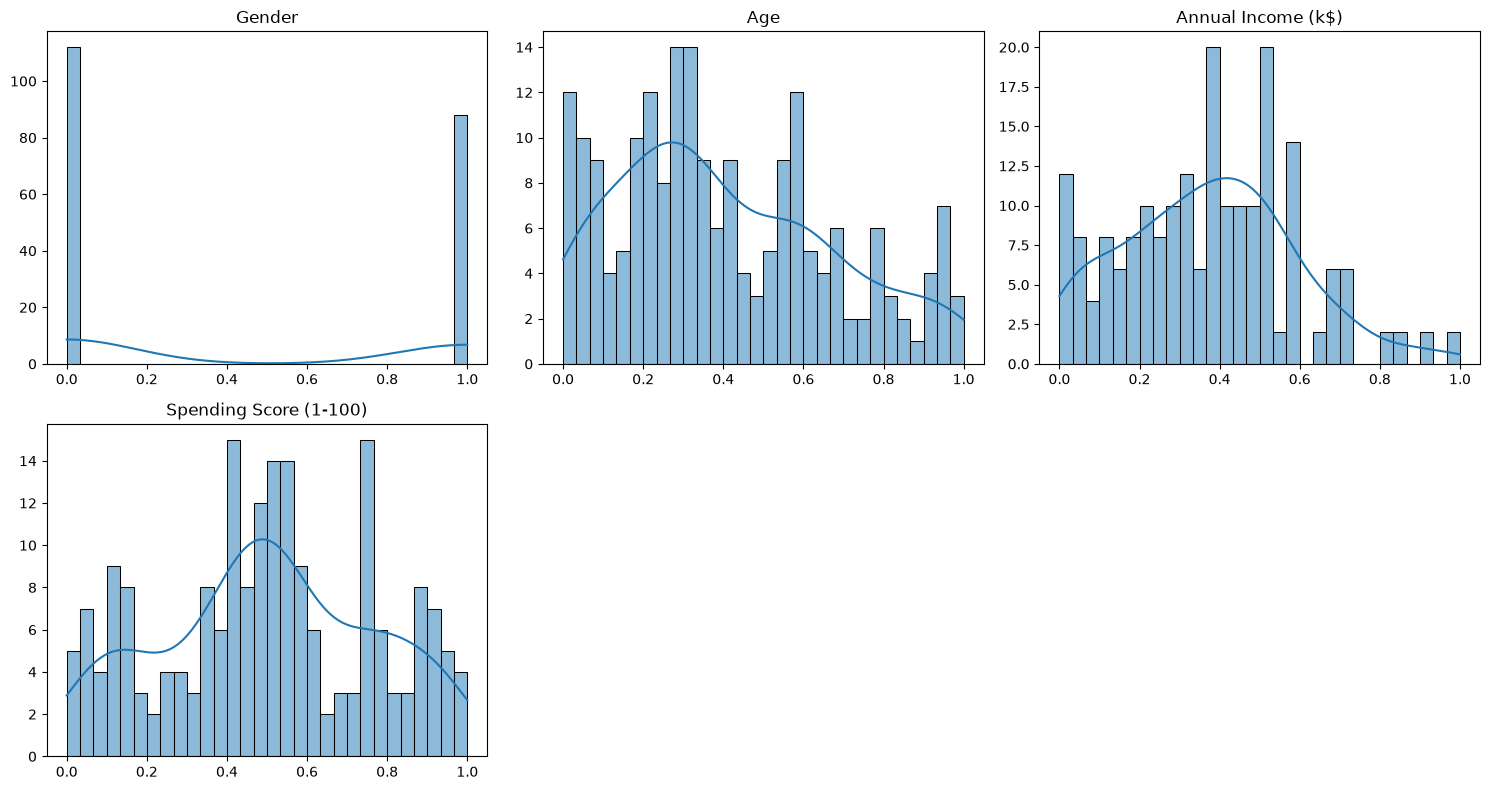

In [16]:
plot_all_histograms(df)

## K-Means Clustering

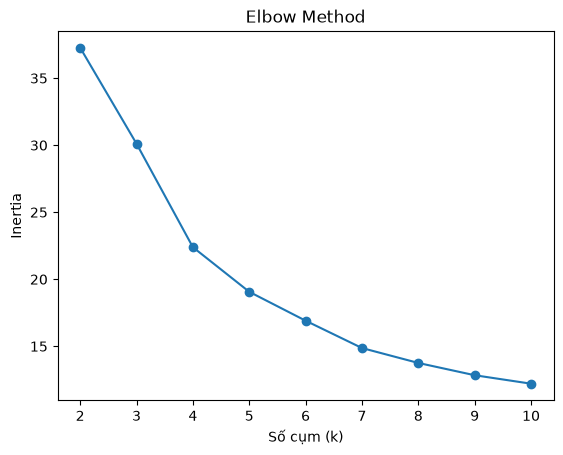

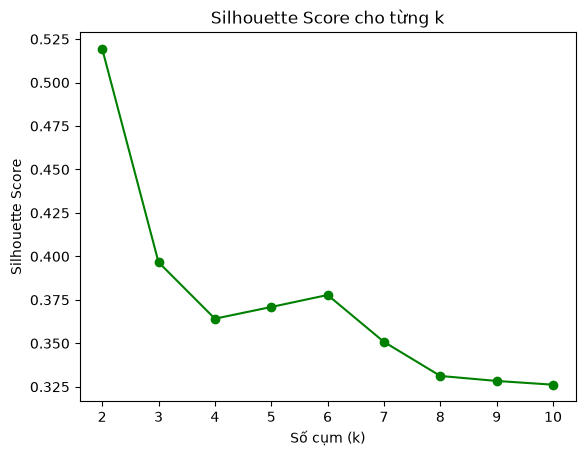

In [17]:
inertia = []
silhouette_scores = []

k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42) # You code here
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Vẽ Elbow Method
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Số cụm (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Vẽ Silhouette Score
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.xlabel('Số cụm (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score cho từng k')
plt.show()


In [18]:
optimal_k = k_values[np.argmax(silhouette_scores)]
print(f"Số cluster tối ưu theo Silhouette Score: {optimal_k}")
print(f"Silhouette Score cao nhất: {max(silhouette_scores):.3f}")

Số cluster tối ưu theo Silhouette Score: 2
Silhouette Score cao nhất: 0.519


In [19]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_scaled)

In [20]:
silhouette_score(df_scaled, cluster_labels)

0.5194624832665107